In [40]:
import os
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")


Using device: mps


In [44]:

TRAIN_PATH = "/Users/ramprasadreddygajjala/Documents/FaceShapeDetection/data/training_set"  
TEST_PATH = "/Users/ramprasadreddygajjala/Documents/FaceShapeDetection/data/testing_set"    

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])


In [45]:
def safe_pil_loader(path):
    try:
        with open(path, 'rb') as f:
            img = Image.open(f)
            return img.convert('RGB')
    except (OSError, SyntaxError):
        return Image.new('RGB', (224, 224))


In [46]:
BATCH_SIZE = 64
NUM_WORKERS = 4

In [47]:

train_dataset = datasets.ImageFolder(root=TRAIN_PATH, transform=train_transforms, loader=safe_pil_loader)
test_dataset = datasets.ImageFolder(root=TEST_PATH, transform=test_transforms, loader=safe_pil_loader)


BATCH_SIZE = 64
NUM_WORKERS = os.cpu_count() - 1  # Adjust this based on your system

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Datasets and DataLoaders successfully created!")


Datasets and DataLoaders successfully created!


In [48]:

print(f"Number of training images: {len(train_dataset)}")
print(f"Number of testing images: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")


Number of training images: 4000
Number of testing images: 1000
Classes: ['Heart', 'Oblong', 'Oval', 'Round', 'Square']


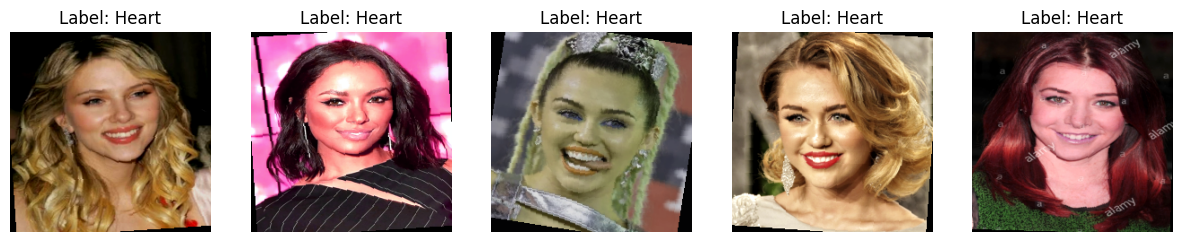

In [49]:
import matplotlib.pyplot as plt


def show_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        image, label = dataset[i]
        image = image.permute(1, 2, 0).numpy()  # Convert from tensor to image format
        image = image * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # Unnormalize
        image = image.clip(0, 1)  # Clip values to [0, 1]
        
        axes[i].imshow(image)
        axes[i].set_title(f"Label: {dataset.classes[label]}")
        axes[i].axis("off")
    plt.show()


show_images(train_dataset)


In [50]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator


IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2
)

test_datagen = ImageDataGenerator(rescale=1.0/255)


train_data = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


Found 4000 images belonging to 5 classes.
Found 1000 images belonging to 5 classes.


In [51]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D


base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')


base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(len(train_data.class_indices), activation='softmax')  
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d_1  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dropout_1 (Dropout)         (None, 1280)              0         
                                                                 
 dense_1 (Dense)             (None, 256)               327936    
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (None, 5)                

In [55]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

EPOCHS = 10

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=EPOCHS
)




Epoch 1/10
125/125 [==============================] - 46s 365ms/step - loss: 1.4484 - accuracy: 0.3762 - val_loss: 1.4557 - val_accuracy: 0.3810
Epoch 2/10
125/125 [==============================] - 45s 361ms/step - loss: 1.4262 - accuracy: 0.3975 - val_loss: 1.4266 - val_accuracy: 0.3860
Epoch 3/10
125/125 [==============================] - 45s 360ms/step - loss: 1.3924 - accuracy: 0.4058 - val_loss: 1.4121 - val_accuracy: 0.4040
Epoch 4/10
125/125 [==============================] - 45s 362ms/step - loss: 1.3548 - accuracy: 0.4448 - val_loss: 1.4140 - val_accuracy: 0.4000
Epoch 5/10
125/125 [==============================] - 45s 361ms/step - loss: 1.3503 - accuracy: 0.4450 - val_loss: 1.4099 - val_accuracy: 0.4060
Epoch 6/10
125/125 [==============================] - 45s 362ms/step - loss: 1.3281 - accuracy: 0.4480 - val_loss: 1.3804 - val_accuracy: 0.4330
Epoch 7/10
125/125 [==============================] - 46s 371ms/step - loss: 1.2915 - accuracy: 0.4697 - val_loss: 1.3931 - val_ac

In [56]:

model.save('saved_model/my_model')


2024-11-21 12:07:52.280150: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


INFO:tensorflow:Assets written to: saved_model/my_model/assets


INFO:tensorflow:Assets written to: saved_model/my_model/assets


In [60]:
import tensorflow as tf

# Load the SavedModel
saved_model_dir = 'saved_model/my_model'
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)

# (Optional) Set optimization flags for a smaller and faster model
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert the model
tflite_model = converter.convert()

# Save the model as a .tflite file
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)


2024-11-21 13:16:22.779742: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2024-11-21 13:16:22.779761: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2024-11-21 13:16:22.779962: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: saved_model/my_model
2024-11-21 13:16:22.793533: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2024-11-21 13:16:22.793551: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: saved_model/my_model
2024-11-21 13:16:22.822029: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2024-11-21 13:16:23.058373: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: saved_model/my_model
2024-11-21 13:16:23.133389: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. 

In [61]:
import numpy as np

# Load the TFLite model
interpreter = tf.lite.Interpreter(model_path='model.tflite')
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Prepare a test input matching the input shape
input_shape = input_details[0]['shape']
input_data = np.array(np.random.random_sample(input_shape), dtype=np.float32)

# Set the input tensor
interpreter.set_tensor(input_details[0]['index'], input_data)

# Run inference
interpreter.invoke()

# Retrieve the output
output_data = interpreter.get_tensor(output_details[0]['index'])
print(output_data)


[[0.65591943 0.11513346 0.2152091  0.01190763 0.00183043]]


In [62]:
import tensorflow as tf

model = tf.lite.Interpreter(model_path="model.tflite")
model.allocate_tensors()

output_details = model.get_output_details()
print("Output shape:", output_details[0]['shape'])


Output shape: [1 5]
